In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [4]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [6]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [8]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [12]:
nav = nav.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [13]:
nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [14]:
nav = nav.sort_values(
    ["scheme_name", "date"]
)

In [15]:
nav["daily_return"] = (
    nav.groupby("scheme_name")["nav"]
       .pct_change()
)

In [16]:
nav.head(15)

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314
3455,101206,2022-01-10,307.5591,ABSL Frontline Equity Fund - Regular - Growth,0.011548
3456,101206,2022-01-11,309.4372,ABSL Frontline Equity Fund - Regular - Growth,0.006106
3457,101206,2022-01-12,313.2022,ABSL Frontline Equity Fund - Regular - Growth,0.012167
3458,101206,2022-01-13,310.7396,ABSL Frontline Equity Fund - Regular - Growth,-0.007863
3459,101206,2022-01-14,308.9641,ABSL Frontline Equity Fund - Regular - Growth,-0.005714


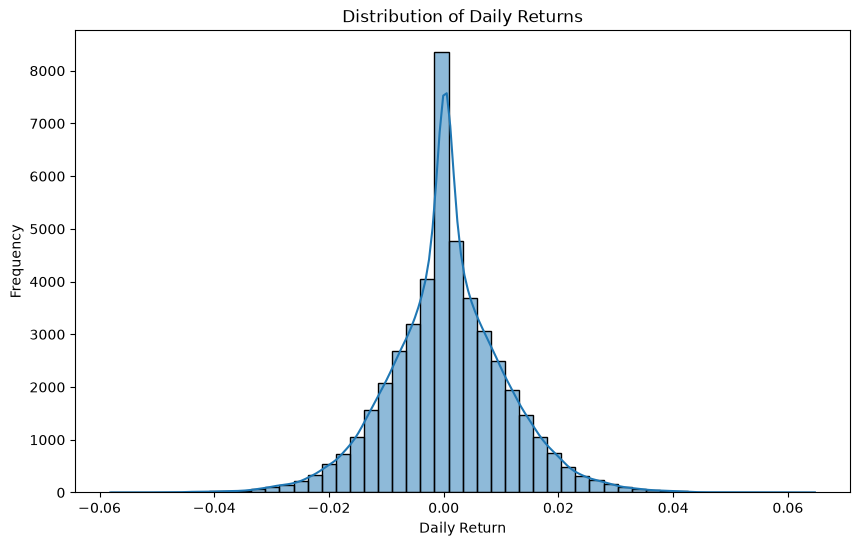

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [18]:
plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [19]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

### Insight 1
The daily return distribution appears realistic, with an average daily return of approximately 0.063% and a standard deviation of about 1.03%, indicating normal market fluctuations.

In [20]:
nav = nav.sort_values(["scheme_name", "date"])

In [21]:
nav.groupby("scheme_name")["date"].agg(["min", "max"])

,min,max
scheme_name,,
ABSL Frontline Equity Fund - Regular - Growth,2022-01-03,2026-05-29
ABSL Liquid Fund - Regular - Growth,2022-01-03,2026-05-29
ABSL Small Cap Fund - Regular - Growth,2022-01-03,2026-05-29
Axis Bluechip Fund - Direct - Growth,2022-01-03,2026-05-29
Axis Bluechip Fund - Regular - Growth,2022-01-03,2026-05-29
Axis Midcap Fund - Regular - Growth,2022-01-03,2026-05-29
Axis Small Cap Fund - Regular - Growth,2022-01-03,2026-05-29
DSP Midcap Fund - Regular - Growth,2022-01-03,2026-05-29
DSP Small Cap Fund - Regular - Growth,2022-01-03,2026-05-29


In [22]:
cagr_data = []

In [23]:
for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"] == scheme]

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] - df.iloc[0]["date"]).days
        / 365.25
    )

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_data.append({
        "scheme_name": scheme,
        "CAGR (%)": round(cagr, 2)
    })

In [24]:
cagr_df = pd.DataFrame(cagr_data)

In [25]:
cagr_df = cagr_df.sort_values(
    "CAGR (%)",
    ascending=False
)

In [26]:
cagr_df.head(10)

,scheme_name,CAGR (%)
18,ICICI Pru Midcap Fund - Regular - Growth,32.83
36,SBI Small Cap Fund - Regular Plan - Growth,32.42
8,DSP Small Cap Fund - Regular - Growth,32.29
26,Mirae Asset Tax Saver Fund - Regular - Growth,31.95
25,Mirae Asset Large Cap Fund - Regular - Growth,30.97
22,Kotak Flexicap Fund - Regular - Growth,30.91
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12
7,DSP Midcap Fund - Regular - Growth,29.58
5,Axis Midcap Fund - Regular - Growth,28.21
33,SBI Bluechip Fund - Regular Plan - Growth,25.80


In [27]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

In [28]:
nav.groupby("scheme_name")["date"].agg(["min", "max"])

,min,max
scheme_name,,
ABSL Frontline Equity Fund - Regular - Growth,2022-01-03,2026-05-29
ABSL Liquid Fund - Regular - Growth,2022-01-03,2026-05-29
ABSL Small Cap Fund - Regular - Growth,2022-01-03,2026-05-29
Axis Bluechip Fund - Direct - Growth,2022-01-03,2026-05-29
Axis Bluechip Fund - Regular - Growth,2022-01-03,2026-05-29
Axis Midcap Fund - Regular - Growth,2022-01-03,2026-05-29
Axis Small Cap Fund - Regular - Growth,2022-01-03,2026-05-29
DSP Midcap Fund - Regular - Growth,2022-01-03,2026-05-29
DSP Small Cap Fund - Regular - Growth,2022-01-03,2026-05-29


In [29]:
cagr_data = []

In [30]:
from datetime import timedelta

for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"] == scheme].sort_values("date")

    latest_date = df["date"].max()

    row = {"scheme_name": scheme}

    # ---------- 1 Year CAGR ----------
    start_date = latest_date - timedelta(days=365)

    df_1 = df[df["date"] >= start_date]

    if len(df_1) > 1:
        start_nav = df_1.iloc[0]["nav"]
        end_nav = df.iloc[-1]["nav"]

        years = (
            (latest_date - df_1.iloc[0]["date"]).days
            / 365.25
        )

        row["CAGR_1yr_pct"] = ((end_nav/start_nav)**(1/years)-1)*100
    else:
        row["CAGR_1yr_pct"] = None


    # ---------- 3 Year CAGR ----------
    start_date = latest_date - timedelta(days=365*3)

    df_3 = df[df["date"] >= start_date]

    if len(df_3) > 1:
        start_nav = df_3.iloc[0]["nav"]
        end_nav = df.iloc[-1]["nav"]

        years = (
            (latest_date-df_3.iloc[0]["date"]).days
            /365.25
        )

        row["CAGR_3yr_pct"] = ((end_nav/start_nav)**(1/years)-1)*100
    else:
        row["CAGR_3yr_pct"] = None


    # ---------- 5 Year CAGR ----------
    start_date = latest_date - timedelta(days=365*5)

    df_5 = df[df["date"] >= start_date]

    if len(df_5) > 1 and (latest_date-df_5.iloc[0]["date"]).days >= 365*5:
        start_nav = df_5.iloc[0]["nav"]
        end_nav = df.iloc[-1]["nav"]

        years = (
            (latest_date-df_5.iloc[0]["date"]).days
            /365.25
        )

        row["CAGR_5yr_pct"] = ((end_nav/start_nav)**(1/years)-1)*100

    else:
        row["CAGR_5yr_pct"] = None

    cagr_data.append(row)

In [31]:
cagr_df = pd.DataFrame(cagr_data)

In [32]:
cagr_df.head()

,scheme_name,CAGR_1yr_pct,CAGR_3yr_pct,CAGR_5yr_pct
0,ABSL Frontline Equity Fund - Regular - Growth,47.963794,28.691350,None
1,ABSL Liquid Fund - Regular - Growth,7.241777,6.319590,None
2,ABSL Small Cap Fund - Regular - Growth,-24.000309,-4.696790,None
3,Axis Bluechip Fund - Direct - Growth,19.781539,20.193301,None
4,Axis Bluechip Fund - Regular - Growth,1.610230,1.229450,None


In [33]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

In [34]:
risk_free_rate = 0.065

In [35]:
sharpe_data = []

In [36]:
for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"] == scheme]

    mean_return = df["daily_return"].mean()

    std_return = df["daily_return"].std()

    annual_return = mean_return * 252

    annual_std = std_return * (252 ** 0.5)

    sharpe = (annual_return - risk_free_rate) / annual_std

    sharpe_data.append({
        "scheme_name": scheme,
        "Sharpe Ratio": sharpe
    })

In [37]:
sharpe_df = pd.DataFrame(sharpe_data)

In [38]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
)

In [39]:
sharpe_df.head(10)

,scheme_name,Sharpe Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
22,Kotak Flexicap Fund - Regular - Growth,1.306744
26,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
33,SBI Bluechip Fund - Regular Plan - Growth,1.208267
18,ICICI Pru Midcap Fund - Regular - Growth,1.180101
7,DSP Midcap Fund - Regular - Growth,1.132122
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
30,Nippon India Large Cap Fund - Regular - Growth,1.081659
0,ABSL Frontline Equity Fund - Regular - Growth,1.027213
15,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


In [40]:
sortino_data = []

In [41]:
for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"] == scheme]

    mean_return = df["daily_return"].mean()

    downside_returns = df[df["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std()

    annual_return = mean_return * 252

    annual_downside_std = downside_std * (252 ** 0.5)

    sortino = (annual_return - risk_free_rate) / annual_downside_std

    sortino_data.append({
        "scheme_name": scheme,
        "Sortino Ratio": sortino
    })

In [42]:
sortino_df = pd.DataFrame(sortino_data)

In [43]:
sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
)

In [44]:
sortino_df.head(10)

,scheme_name,Sortino Ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
22,Kotak Flexicap Fund - Regular - Growth,2.364320
26,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
33,SBI Bluechip Fund - Regular Plan - Growth,2.140267
18,ICICI Pru Midcap Fund - Regular - Growth,2.029353
7,DSP Midcap Fund - Regular - Growth,1.875101
30,Nippon India Large Cap Fund - Regular - Growth,1.850133
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
15,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
0,ABSL Frontline Equity Fund - Regular - Growth,1.799563


In [45]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [46]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [47]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

In [48]:
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [49]:
alpha_beta = []

In [50]:
from scipy.stats import linregress

for scheme in nav["scheme_name"].unique():

    fund = nav[nav["scheme_name"] == scheme].copy()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "scheme_name": scheme,
        "Alpha": intercept * 252,
        "Beta": slope
    })

In [51]:
alpha_beta_df = pd.DataFrame(alpha_beta)

In [52]:
alpha_beta_df.head(10)

,scheme_name,Alpha,Beta
0,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
1,ABSL Liquid Fund - Regular - Growth,0.060861,0.000267
2,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289
3,Axis Bluechip Fund - Direct - Growth,0.082328,0.025883
4,Axis Bluechip Fund - Regular - Growth,0.068995,0.009731
5,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265
6,Axis Small Cap Fund - Regular - Growth,0.048016,-0.066951
7,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523
8,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455
9,DSP Top 100 Equity Fund - Regular - Growth,0.131732,-0.004050


In [53]:
drawdown_results = []

In [54]:
for scheme in nav["scheme_name"].unique():

    df = nav[nav["scheme_name"] == scheme].copy()

    df = df.sort_values("date")

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (df["nav"] / df["running_max"]) - 1

    worst_row = df.loc[df["drawdown"].idxmin()]

    drawdown_results.append({
        "scheme_name": scheme,
        "Maximum Drawdown": worst_row["drawdown"],
        "Worst Date": worst_row["date"]
    })

In [55]:
drawdown_df = pd.DataFrame(drawdown_results)

In [56]:
drawdown_df = drawdown_df.sort_values(
    "Maximum Drawdown"
)

In [57]:
drawdown_df.head(10)

,scheme_name,Maximum Drawdown,Worst Date
35,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2025-10-28
6,Axis Small Cap Fund - Regular - Growth,-0.516778,2026-05-11
2,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11
8,DSP Small Cap Fund - Regular - Growth,-0.311719,2025-01-03
36,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2025-05-14
38,UTI Mid Cap Fund - Regular - Growth,-0.280011,2026-04-27
14,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-09-15
21,Kotak Emerging Equity Fund - Regular - Growth,-0.240035,2024-10-17
31,Nippon India Small Cap Fund - Regular - Growth,-0.233449,2026-02-20
3,Axis Bluechip Fund - Direct - Growth,-0.217514,2023-05-22


In [58]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="scheme_name"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="scheme_name"
)

scorecard = scorecard.merge(
    drawdown_df[["scheme_name", "Maximum Drawdown"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    performance[["scheme_name", "expense_ratio_pct"]],
    on="scheme_name"
)

scorecard.head()

,scheme_name,CAGR_1yr_pct,CAGR_3yr_pct,CAGR_5yr_pct,Sharpe Ratio,Alpha,Beta,Maximum Drawdown,expense_ratio_pct
0,ABSL Frontline Equity Fund - Regular - Growth,47.963794,28.691350,None,1.027213,0.213998,0.021086,-0.112916,1.60
1,ABSL Liquid Fund - Regular - Growth,7.241777,6.319590,None,-0.815567,0.060861,0.000267,-0.001622,0.79
2,ABSL Small Cap Fund - Regular - Growth,-24.000309,-4.696790,None,0.162661,0.108971,-0.065289,-0.354469,1.53
3,Axis Bluechip Fund - Direct - Growth,19.781539,20.193301,None,0.129614,0.082328,0.025883,-0.217514,0.75
4,Axis Bluechip Fund - Regular - Growth,1.610230,1.229450,None,0.030785,0.068995,0.009731,-0.144016,1.64


In [59]:
scorecard["return_rank"] = scorecard["CAGR_3yr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = scorecard["Maximum Drawdown"].rank(ascending=False)

In [60]:
scorecard["Fund Score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

In [61]:
scorecard["Fund Score"] = 100 * (
    scorecard["Fund Score"].max() - scorecard["Fund Score"]
) / (
    scorecard["Fund Score"].max() - scorecard["Fund Score"].min()
)

In [62]:
scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
)

scorecard.head(10)

,scheme_name,CAGR_1yr_pct,CAGR_3yr_pct,CAGR_5yr_pct,Sharpe Ratio,Alpha,Beta,Maximum Drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund Score
25,Mirae Asset Large Cap Fund - Regular - Growth,20.375957,34.189711,None,1.448291,0.269838,0.023684,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,100.000000
18,ICICI Pru Midcap Fund - Regular - Growth,29.627681,31.542575,None,1.180101,0.292636,0.000549,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,94.492255
22,Kotak Flexicap Fund - Regular - Growth,26.677584,29.714985,None,1.306744,0.273305,-0.022830,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,94.148021
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.277195,32.472393,None,1.093699,0.271954,0.005104,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,92.426850
15,ICICI Pru Bluechip Fund - Direct - Growth,13.073788,33.170883,None,1.026524,0.211948,0.016232,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,91.394148
5,Axis Midcap Fund - Regular - Growth,22.277897,35.362416,None,0.998231,0.260767,-0.066265,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,87.263339
33,SBI Bluechip Fund - Regular Plan - Growth,60.489297,30.371874,None,1.208267,0.232010,-0.031751,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,84.251291
26,Mirae Asset Tax Saver Fund - Regular - Growth,39.783803,28.414382,None,1.234930,0.282704,0.018134,-0.163967,1.60,9.0,3.0,4.0,36.5,21.0,81.669535
0,ABSL Frontline Equity Fund - Regular - Growth,47.963794,28.691350,None,1.027213,0.213998,0.021086,-0.112916,1.60,8.0,9.0,12.0,36.5,9.0,76.161790
36,SBI Small Cap Fund - Regular Plan - Growth,82.851575,26.090498,None,0.945308,0.303370,-0.023196,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,74.010327


In [63]:
top5 = scorecard.head(5)["scheme_name"].tolist()

top5

['Mirae Asset Large Cap Fund - Regular - Growth',
 'ICICI Pru Midcap Fund - Regular - Growth',
 'Kotak Flexicap Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 'ICICI Pru Bluechip Fund - Direct - Growth']

In [64]:
benchmark.groupby("index_name")["date"].agg(["min", "max"])

,min,max
index_name,,
BSE_SMALLCAP,2022-01-03,2026-05-29
CRISIL_GILT,2022-01-03,2026-05-29
CRISIL_LIQUID,2022-01-03,2026-05-29
NIFTY100,2022-01-03,2026-05-29
NIFTY50,2022-01-03,2026-05-29
NIFTY500,2022-01-03,2026-05-29
NIFTY_MIDCAP150,2022-01-03,2026-05-29


In [65]:
benchmark_compare = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_compare = benchmark_compare.sort_values(
    ["index_name", "date"]
)

benchmark_compare["Normalized Value"] = (
    benchmark_compare.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

benchmark_compare.head()

,date,index_name,close_value,Normalized Value
1150,2022-01-03,NIFTY100,17778.24,100.000000
1151,2022-01-04,NIFTY100,17537.52,98.645985
1152,2022-01-05,NIFTY100,17607.73,99.040906
1153,2022-01-06,NIFTY100,17556.05,98.750214
1154,2022-01-07,NIFTY100,17664.02,99.357529


In [66]:
top5_nav = nav[
    nav["scheme_name"].isin(top5)
].copy()

top5_nav = top5_nav.sort_values(
    ["scheme_name", "date"]
)

top5_nav["Normalized Value"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

top5_nav.head()

,amfi_code,date,nav,scheme_name,daily_return,Normalized Value
2300,100033,2022-01-03,107.3758,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NaN,100.000000
2301,100033,2022-01-04,105.9447,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.013328,98.667204
2302,100033,2022-01-05,105.4800,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.004386,98.234425
2303,100033,2022-01-06,104.9350,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005167,97.726862
2304,100033,2022-01-07,104.3318,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005748,97.165097


In [67]:
import plotly.graph_objects as go

fig = go.Figure()

In [68]:
for scheme in top5:

    temp = top5_nav[top5_nav["scheme_name"] == scheme]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["Normalized Value"],
            mode="lines",
            name=scheme
        )
    )

In [69]:
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_compare[
        benchmark_compare["index_name"] == index
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["Normalized Value"],
            mode="lines",
            name=index,
            line=dict(width=4)
        )
    )

In [70]:
fig.update_layout(
    title="Top 5 Mutual Funds vs NIFTY50 & NIFTY100",
    xaxis_title="Date",
    yaxis_title="Normalized Value (Base = 100)",
    template="plotly_white",
    height=700
)

fig.show()

In [71]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [72]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [73]:
fig.write_image(
    "../reports/charts/benchmark_comparison.png"
)